In [1]:
!pip install -q kagglehub

In [2]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import kagglehub

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed fixed:", SEED)

Seed fixed: 42


In [4]:
dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset downloaded to:
/kaggle/input/chest-xray-pneumonia


In [5]:
dataset_path = Path(dataset_path)

def find_chest_xray_root(start_path):
    start_path = Path(start_path)

    for root, dirs, files in os.walk(start_path):
        root_path = Path(root)

        has_train = (root_path / "train").exists()
        has_test = (root_path / "test").exists()
        has_val = (root_path / "val").exists()

        if has_train and has_test and has_val:
            train_normal = root_path / "train" / "NORMAL"
            train_pneumonia = root_path / "train" / "PNEUMONIA"

            if train_normal.exists() and train_pneumonia.exists():
                return root_path

    return None

DATA_ROOT = find_chest_xray_root(dataset_path)

print("Detected DATA_ROOT:")
print(DATA_ROOT)

print("\nFolders inside DATA_ROOT:")
print(os.listdir(DATA_ROOT))

Detected DATA_ROOT:
/kaggle/input/chest-xray-pneumonia/chest_xray

Folders inside DATA_ROOT:
['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [6]:
splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

data_summary = []

for split in splits:
    for cls in classes:
        folder = DATA_ROOT / split / cls
        image_files = list(folder.glob("*"))
        image_files = [f for f in image_files if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]

        data_summary.append({
            "split": split,
            "class": cls,
            "count": len(image_files)
        })

summary_df = pd.DataFrame(data_summary)
summary_df

,split,class,count
0,train,NORMAL,1341
1,train,PNEUMONIA,3875
2,val,NORMAL,8
3,val,PNEUMONIA,8
4,test,NORMAL,234
5,test,PNEUMONIA,390


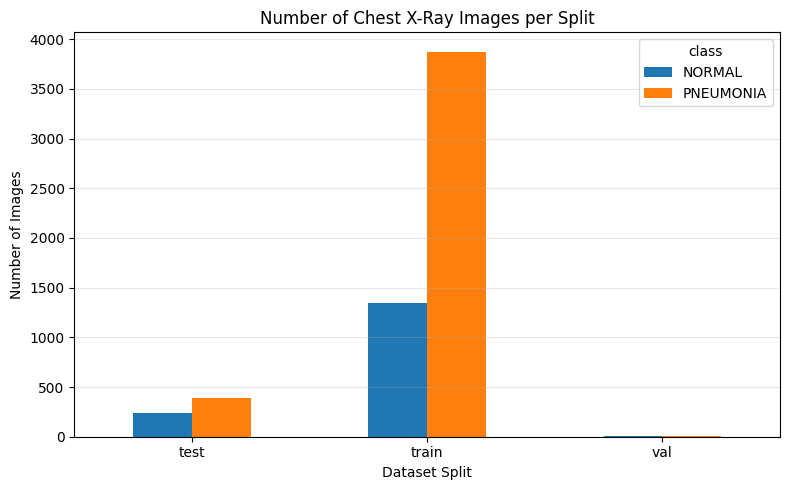

In [7]:
pivot_df = summary_df.pivot(index="split", columns="class", values="count")

ax = pivot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Number of Chest X-Ray Images per Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

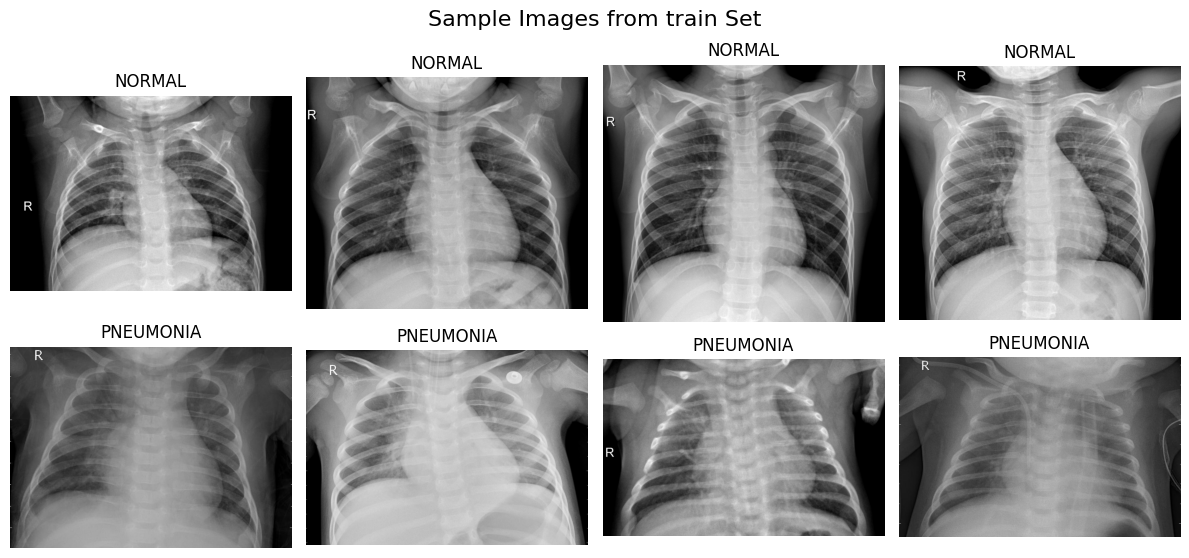

In [8]:
def show_sample_images(split="train", num_images=4):
    plt.figure(figsize=(12, 6))

    image_index = 1

    for cls in classes:
        folder = DATA_ROOT / split / cls
        image_files = list(folder.glob("*"))
        image_files = [f for f in image_files if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]

        selected_images = random.sample(image_files, num_images)

        for img_path in selected_images:
            img = tf.keras.utils.load_img(img_path, color_mode="rgb")

            plt.subplot(len(classes), num_images, image_index)
            plt.imshow(img, cmap="gray")
            plt.title(cls)
            plt.axis("off")

            image_index += 1

    plt.suptitle(f"Sample Images from {split} Set", fontsize=16)
    plt.tight_layout()
    plt.show()

show_sample_images(split="train", num_images=4)

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = DATA_ROOT / "train"
test_dir = DATA_ROOT / "test"

print("Train directory:", train_dir)
print("Test directory:", test_dir)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Train directory: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Test directory: /kaggle/input/chest-xray-pneumonia/chest_xray/test
Image size: (224, 224)
Batch size: 32


In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

class_names = train_ds.class_names

print("Class names:", class_names)

Found 5216 files belonging to 2 classes.
Using 4434 files for training.
Found 5216 files belonging to 2 classes.
Using 782 files for validation.
Class names: ['NORMAL', 'PNEUMONIA']


In [11]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Test dataset created successfully.")

Found 624 files belonging to 2 classes.
Test dataset created successfully.


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets optimized with cache and prefetch.")

Datasets optimized with cache and prefetch.


In [13]:
for images, labels in train_ds.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)
    print("Image pixel range:", tf.reduce_min(images).numpy(), "to", tf.reduce_max(images).numpy())
    print("First 10 labels:", labels[:10].numpy().reshape(-1))

Images batch shape: (32, 224, 224, 3)
Labels batch shape: (32, 1)
Image pixel range: 0.0 to 255.0
First 10 labels: [1. 1. 1. 1. 1. 0. 0. 0. 1. 1.]


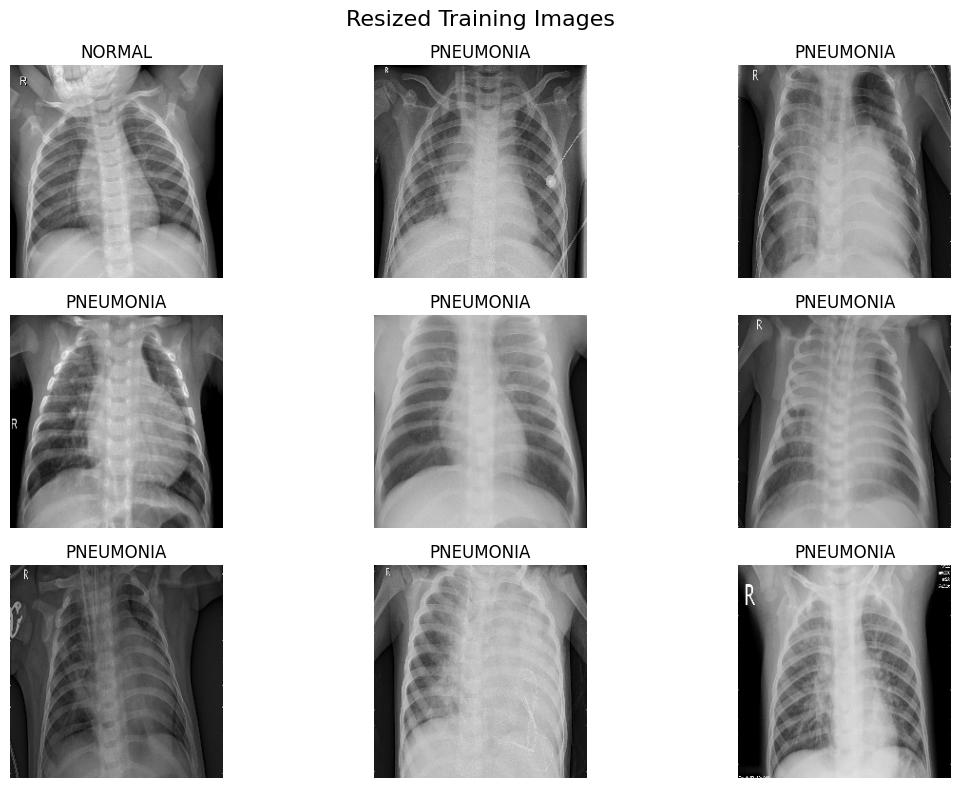

In [14]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label_value = int(labels[i].numpy()[0])
        plt.title(class_names[label_value])
        plt.axis("off")

plt.suptitle("Resized Training Images", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
!nvidia-smi

Wed Apr 29 19:58:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P0             27W /   70W |     147MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
OUTPUT_DIR = Path("outputs")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Output folders created:")
print("Checkpoints:", CHECKPOINT_DIR)
print("Figures:", FIGURE_DIR)
print("Logs:", LOG_DIR)

Output folders created:
Checkpoints: outputs/checkpoints
Figures: outputs/figures
Logs: outputs/logs


In [17]:
normal_count = summary_df[
    (summary_df["split"] == "train") & (summary_df["class"] == "NORMAL")
]["count"].values[0]

pneumonia_count = summary_df[
    (summary_df["split"] == "train") & (summary_df["class"] == "PNEUMONIA")
]["count"].values[0]

total_count = normal_count + pneumonia_count

class_weight = {
    0: total_count / (2 * normal_count),
    1: total_count / (2 * pneumonia_count)
}

print("Class counts:")
print("NORMAL:", normal_count)
print("PNEUMONIA:", pneumonia_count)

print("\nClass weights:")
print(class_weight)

Class counts:
NORMAL: 1341
PNEUMONIA: 3875

Class weights:
{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [18]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


In [19]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [21]:
checkpoint_path = CHECKPOINT_DIR / "best_mobilenetv2_model.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks are ready.")

Callbacks are ready.


In [22]:
EPOCHS = 8

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6251 - auc: 0.7404 - loss: 0.6128 - precision: 0.8809 - recall: 0.5653
Epoch 1: val_loss improved from None to 0.41690, saving model to outputs/checkpoints/best_mobilenetv2_model.keras

Epoch 1: finished saving model to outputs/checkpoints/best_mobilenetv2_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - accuracy: 0.7039 - auc: 0.7882 - loss: 0.5597 - precision: 0.8884 - recall: 0.6863 - val_accuracy: 0.8747 - val_auc: 0.9411 - val_loss: 0.4169 - val_precision: 0.9540 - val_recall: 0.8767 - learning_rate: 1.0000e-04
Epoch 2/8
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7854 - auc: 0.8672 - loss: 0.4752 - precision: 0.9124 - recall: 0.7865
Epoch 2: val_loss improved from 0.41690 to 0.34024, saving model to outputs/checkpoints/best_mobilenetv2_model.keras

Epoch 2: finished saving model to outputs/checkpoints/best_mobilenetv2_model.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 29s 64ms/step - accuracy: 0.7927 - a

In [23]:
history_df = pd.DataFrame(history.history)
history_csv_path = LOG_DIR / "training_history.csv"

history_df.to_csv(history_csv_path, index=False)

print("Training history saved to:")
print(history_csv_path)

history_df

Training history saved to:
outputs/logs/training_history.csv


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,0.703879,0.788214,0.559667,0.888407,0.686263,0.874680,0.941105,0.416899,0.954044,0.876689,0.0001
1,0.792738,0.882136,0.455128,0.920641,0.787999,0.900256,0.959513,0.340236,0.968978,0.896959,0.0001
2,0.833559,0.921142,0.387408,0.941381,0.826683,0.911765,0.965052,0.292622,0.972875,0.908784,0.0001
3,0.853405,0.934773,0.355560,0.947333,0.849223,0.915601,0.967812,0.269244,0.974729,0.912162,0.0001
4,0.875507,0.953017,0.310659,0.959300,0.868718,0.919437,0.969661,0.237438,0.969805,0.922297,0.0001
5,0.888137,0.958872,0.289199,0.966209,0.879683,0.923274,0.970839,0.223575,0.971631,0.925676,0.0001
6,0.892873,0.963655,0.271845,0.967066,0.885471,0.925831,0.971475,0.211231,0.968421,0.932432,0.0001
7,0.894903,0.966169,0.258462,0.966855,0.888517,0.929668,0.972373,0.197911,0.965338,0.940878,0.0001


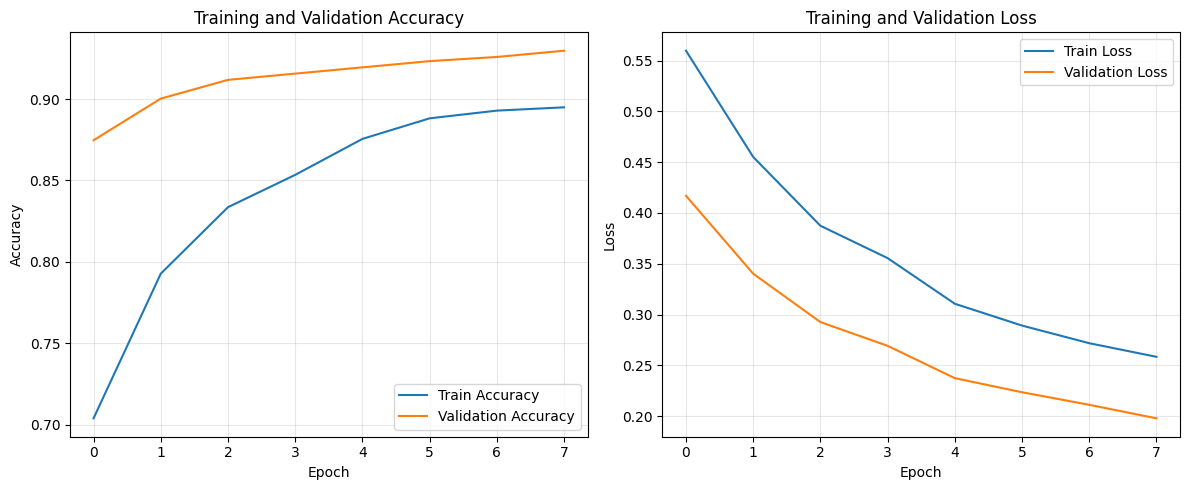

Training curves saved to:
outputs/figures/training_curves.png


In [24]:
def plot_training_curves(history_df, save_path):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["accuracy"], label="Train Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history_df["loss"], label="Train Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

training_curves_path = FIGURE_DIR / "training_curves.png"
plot_training_curves(history_df, training_curves_path)

print("Training curves saved to:")
print(training_curves_path)

In [25]:
test_results = model.evaluate(test_ds, verbose=1)

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.8301 - auc: 0.9427 - loss: 0.3550 - precision: 0.8060 - recall: 0.9590
loss: 0.3550
compile_metrics: 0.8301


In [26]:
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().reshape(-1))
    y_prob.extend(probs.reshape(-1))

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

print("Number of test samples:", len(y_true))
print("First 10 true labels:", y_true[:10])
print("First 10 predicted labels:", y_pred[:10])
print("First 10 predicted probabilities:", y_prob[:10])

Number of test samples: 624
First 10 true labels: [0 0 0 0 0 0 0 0 0 0]
First 10 predicted labels: [0 0 0 1 0 0 0 0 0 0]
First 10 predicted probabilities: [0.30869505 0.17372265 0.33044425 0.73061335 0.20046899 0.11790125
 0.39305854 0.41870528 0.4919491  0.10926311]


In [27]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import itertools

print("Evaluation libraries imported.")

Evaluation libraries imported.


In [28]:
target_names = class_names

report = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4
)

print("Classification Report:")
print(report)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_csv_path = LOG_DIR / "classification_report.csv"

report_df.to_csv(report_csv_path)

print("\nClassification report saved to:")
print(report_csv_path)

report_df

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.9000    0.6154    0.7310       234
   PNEUMONIA     0.8060    0.9590    0.8759       390

    accuracy                         0.8301       624
   macro avg     0.8530    0.7872    0.8034       624
weighted avg     0.8413    0.8301    0.8215       624


Classification report saved to:
outputs/logs/classification_report.csv


,precision,recall,f1-score,support
NORMAL,0.900000,0.615385,0.730964,234.000000
PNEUMONIA,0.806034,0.958974,0.875878,390.000000
accuracy,0.830128,0.830128,0.830128,0.830128
macro avg,0.853017,0.787179,0.803421,624.000000
weighted avg,0.841272,0.830128,0.821536,624.000000


In [29]:
final_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred),
    "Recall": recall_score(y_true, y_pred),
    "F1-score": f1_score(y_true, y_pred)
}

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_path = LOG_DIR / "final_metrics.csv"

final_metrics_df.to_csv(final_metrics_path, index=False)

print("Final Test Metrics:")
display(final_metrics_df)

print("Final metrics saved to:")
print(final_metrics_path)

Final Test Metrics:


,Accuracy,Precision,Recall,F1-score
0,0.830128,0.806034,0.958974,0.875878


Final metrics saved to:
outputs/logs/final_metrics.csv


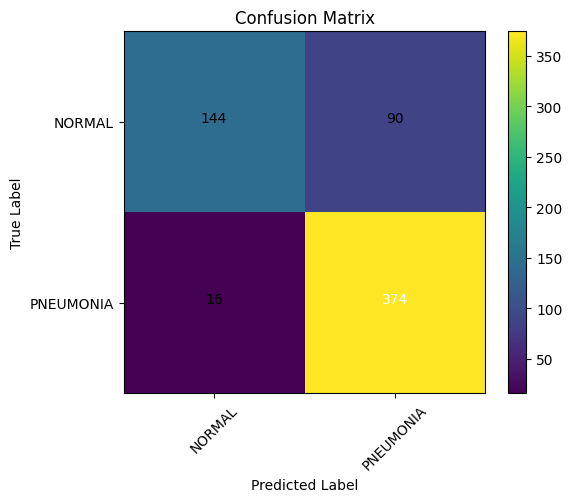

Confusion matrix saved to:
outputs/figures/confusion_matrix.png


In [30]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

threshold = cm.max() / 2

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j], "d"),
        horizontalalignment="center",
        color="white" if cm[i, j] > threshold else "black"
    )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

confusion_matrix_path = FIGURE_DIR / "confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:")
print(confusion_matrix_path)

In [31]:
test_file_paths = []

for class_name in class_names:
    class_folder = test_dir / class_name
    image_files = list(class_folder.glob("*"))
    image_files = [f for f in image_files if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    test_file_paths.extend(image_files)

test_file_paths = sorted(test_file_paths)

results_df = pd.DataFrame({
    "image_path": [str(p) for p in test_file_paths],
    "true_label": [class_names[label] for label in y_true],
    "predicted_label": [class_names[label] for label in y_pred],
    "pneumonia_probability": y_prob
})

results_csv_path = LOG_DIR / "test_predictions.csv"
results_df.to_csv(results_csv_path, index=False)

print("Prediction results saved to:")
print(results_csv_path)

results_df.head()

Prediction results saved to:
outputs/logs/test_predictions.csv


,image_path,true_label,predicted_label,pneumonia_probability
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,NORMAL,0.308695
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,NORMAL,0.173723
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,NORMAL,0.330444
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,PNEUMONIA,0.730613
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,NORMAL,0.200469


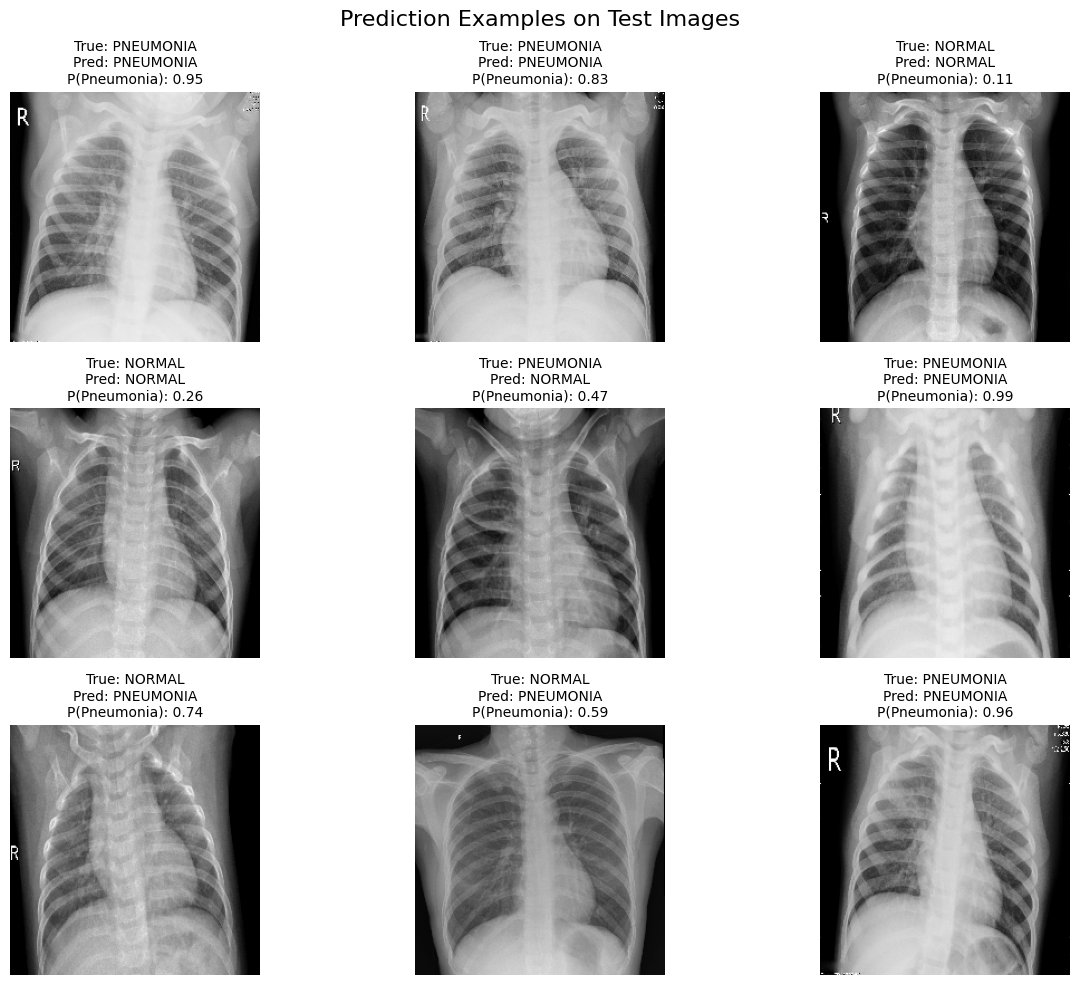

Prediction examples saved to:
outputs/figures/prediction_examples.png


In [32]:
def show_prediction_examples(results_df, num_images=9, save_path=None):
    sample_df = results_df.sample(num_images, random_state=SEED).reset_index(drop=True)

    plt.figure(figsize=(13, 10))

    for i, row in sample_df.iterrows():
        img = tf.keras.utils.load_img(row["image_path"], target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img).astype("uint8")

        true_label = row["true_label"]
        pred_label = row["predicted_label"]
        prob = row["pneumonia_probability"]

        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(img_array)
        plt.axis("off")

        title = f"True: {true_label}\nPred: {pred_label}\nP(Pneumonia): {prob:.2f}"
        plt.title(title, fontsize=10)

    plt.suptitle("Prediction Examples on Test Images", fontsize=16)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

prediction_examples_path = FIGURE_DIR / "prediction_examples.png"
show_prediction_examples(results_df, num_images=9, save_path=prediction_examples_path)

print("Prediction examples saved to:")
print(prediction_examples_path)

In [33]:
wrong_df = results_df[results_df["true_label"] != results_df["predicted_label"]]

print("Number of wrong predictions:", len(wrong_df))
wrong_df.head()

Number of wrong predictions: 106


,image_path,true_label,predicted_label,pneumonia_probability
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,PNEUMONIA,0.730613
10,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,PNEUMONIA,0.792762
14,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,PNEUMONIA,0.636293
16,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,PNEUMONIA,0.955045
18,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL,PNEUMONIA,0.507616


In [34]:
final_model_path = CHECKPOINT_DIR / "final_chest_xray_pneumonia_model.keras"

model.save(final_model_path)

print("Final model saved to:")
print(final_model_path)

Final model saved to:
outputs/checkpoints/final_chest_xray_pneumonia_model.keras
